---

digital brain MEG pipeline

---

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# load pgl
from pgl import pgl, pglActions, pglChoose, pglSession
pgl = pgl()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.14 | packaged by conda-forge | (main, Aug 21 2026, 22:39:36) [Clang 19.1.7 ]
(pgl:checkOS) Running on MacBook Pro (MacBookPro18,3) with macOS version: 26.6.2
(pgl:checkOS) Apple M1 Pro Cores: 8 (6 Performance and 2 Efficiency) Memory: 32 GB
(pgl:checkOS) GPU: Apple M1 Pro (Built-In) 14 cores, Metal 4 support
(pgl:checkOS)   Color LCD [Main Display]: 3024 x 1964 Retina (Built-in Liquid Retina XDR Display) GammaTable size: 1024
(pglBase) Main library instance created


---

load session

---

In [ ]:

# Load the session
loadSession = pglActions.loadSession()
loadSession.configure()
if loadSession: session = loadSession.run()

---

Load FieldLine data

---

In [2]:
# configure the load
loadFieldline = pglActions.loadFieldline()
loadFieldline.configure(dataPath='/Users/justin/Desktop/digitalbrain')


In [3]:
# and run it
session=loadFieldline.run()

(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_105019_sub-S004_file-ThingsPilotRun07_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/sub-S004_file-ThingsPilotRun01_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_103412_sub-S004_file-ThingsPilotRun03_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_102956_sub-S004_file-ThingsPilotRun02_raw.fif
(loadFieldline:_run) Loading Fieldline FIF file:
/Users/justin/Desktop/digitalbrain/MEG-OPM/s0004/2026-08-25/20260825_104244_sub-S004_file-ThingsPilotRun05_raw.fif
(loadFieldline:_run) Loading Fie

---

Concatenate raws

---

In [4]:
# configure the concatenation
mneConcatenate = pglActions.mneConcatenate()
mneConcatenate.configure(session, all=True)

In [5]:
# run the concatenation
session = mneConcatenate.run(session)

(mneConcatenate:_run) 20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) 20260825_110653_sub-S004_file-ThingsPilotRun11_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) 20260825_110245_sub-S004_file-ThingsPilotRun10_raw.fif has bads: ['L117_bz-s113', 'L203_bz-s67', 'L504_bz-s86',
'L605_bz-s90'], which do not match the most common set: ['L203_bz-s67', 'L504_bz-s86', 'L605_bz-s90']
(mneConcatenate:_run) Set bads for concatenation to: {'L605_bz-s90', 'L504_bz-s86', 'L117_bz-s113', 'L203_bz-s67'}


---

Set names of events

---

In [6]:
# configure the concatenation
mneConfigureEvents = pglActions.mneConfigureEvents()

# group all the things labels into one
grouped = {
    'things': range(2,201),
    'blank': 1022,
    'catch': 1023
}

# label each stimulus with its own name
each = {
    f"stimulus {code:03d}": code
    for code in range(2, 201)
}
each["blank"] = 1022
each["catch"] = 1023

# configure
mneConfigureEvents.configure(triggerLabelNames=['grouped','each'],triggerLabels=[grouped,each])

Finding events on: di2


2290 events found on stim channel di2
Event IDs: [   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  165  166  167  168  169
  170  171  172  173  174  175  176  177  178  179  180  181  182  183
  184  185  186  187  188  1

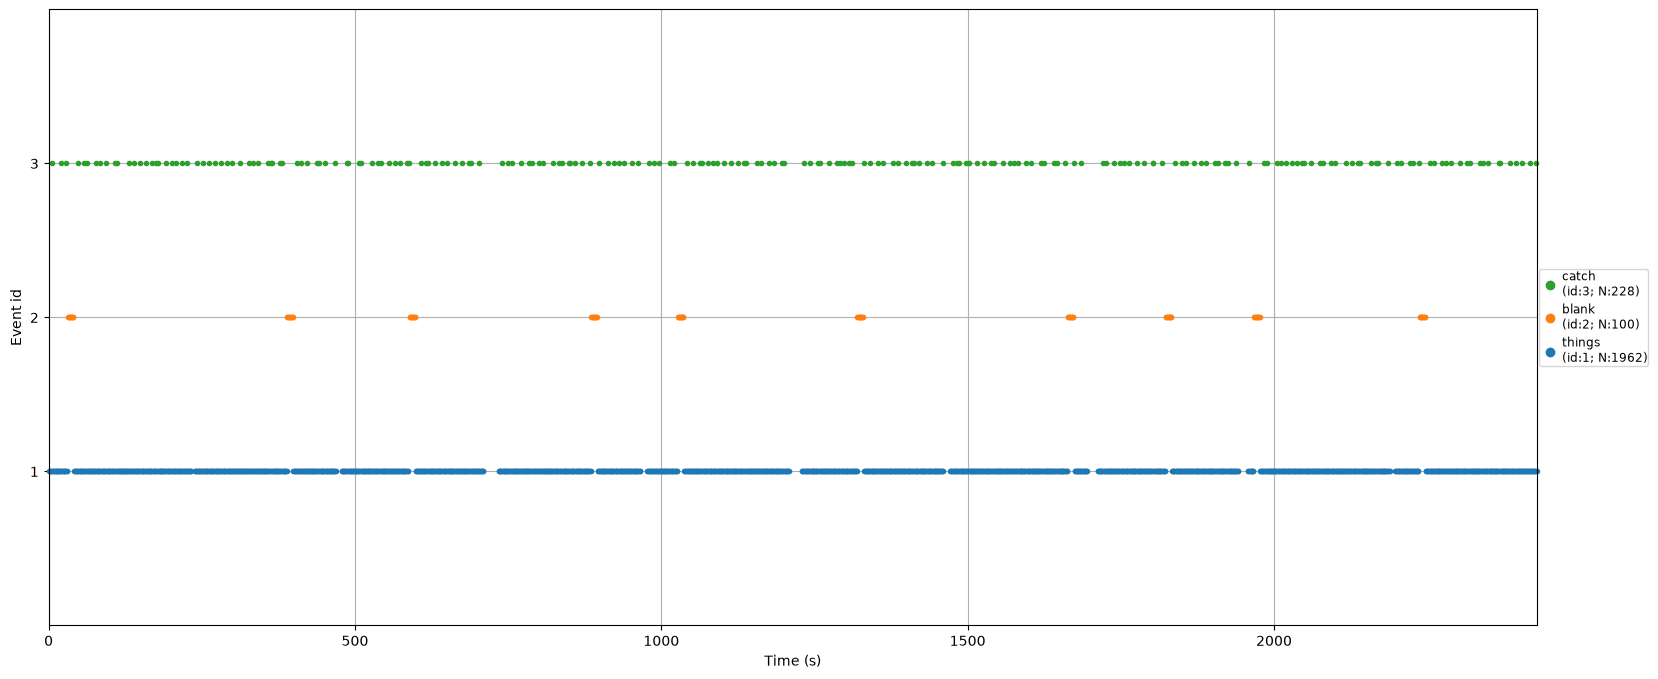

In [13]:
# configure the events
session = mneConfigureEvents.run(session)

In [14]:
session.mne.events.grouped

array([[   1175,       0,       1],
       [   2196,       0,       1],
       [   3195,       0,       1],
       ...,
       [2426603,       0,       1],
       [2427607,       0,       3],
       [2428628,       0,       1]], shape=(2290, 3))

In [ ]:
session.mne.eventLabels

In [ ]:
from pgl import pglChooseFieldlineData, pglDialog
choose = pglChooseFieldlineData(dataPath="/Users/justin/Desktop/digitalbrain")
choose.print()
#pgl.traitsDialog(choose)